In [116]:
from dotenv import load_dotenv
import os

os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [117]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model='openai:gpt-4o')
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000159CF5B71D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000159CF5B72F0>, root_client=<openai.OpenAI object at 0x00000159D089EC60>, root_async_client=<openai.AsyncOpenAI object at 0x00000159D089FD40>, model_name='gpt-4o', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [118]:
from typing import Annotated, List, Dict, Optional, Literal
from typing_extensions import TypedDict

from pathlib import Path
from tempfile import TemporaryDirectory

from langchain_core.language_models.chat_models import BaseChatModel

from langgraph.graph.message import MessagesState
from langgraph.graph import END
from langgraph.types import Command

from langchain_tavily import TavilySearch
from langchain_core.tools import Tool, tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import TextLoader, WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import HumanMessage, BaseMessage
from langchain.agents import create_agent

In [119]:
tavily_tool = TavilySearch(max_results=5)

In [120]:
class State(MessagesState):
    next:str

In [121]:
def make_supervisor_node(llm:BaseChatModel, members:List[str])->str:
    options = members + ["FINISH"]
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a"
        " task and respond with their results and status. When finished,"
        " respond with FINISH."
    )

    # type of a dictionary
    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""
        next: Literal[*options]

    def supervisor_node(state:State)->Command[Literal[*members, "__end__"]]:
        """An LLM-based router."""
        messages = [
            {"role":"system", "content":system_prompt}
        ] + state['messages']
        response = llm.with_structured_output(Router).invoke(messages) # force model to response with the dict type above
        goto = response['next']
        if goto == 'FINISH':
            goto = END

        return Command(goto=goto, update={"next":goto})
    
    return supervisor_node

In [122]:
def make_retrieval_tool(path, name, desc):
    docs = TextLoader(path, encoding='utf-8').load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vector_store = FAISS.from_documents(
        documents=chunks,
        embedding=OpenAIEmbeddings()
    )
    retriever = vector_store.as_retriever()

    def tool_fn(query:str)->str:
        print(f"Using {name}")
        results = retriever.invoke(query)
        return '\n\n'.join([doc.page_content for doc in results])
    
    return Tool(name=name, description=desc, func=tool_fn)

In [123]:
internal_tool_1 = make_retrieval_tool('internal_docs.txt', 
                                      'InternalResearchNotes',
                                       'Search internal research notes for experimental results')

In [124]:
search_agent = create_agent(
    llm,
    tools=[tavily_tool,internal_tool_1]
)

def search_node(state:State)->Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(content=result['messages'][-1].content, name='search')
            ]
        },
        goto='supervisor'
    )

In [125]:
research_supervisor_node = make_supervisor_node(llm, ['search'])
research_supervisor_node

<function __main__.make_supervisor_node.<locals>.supervisor_node(state: __main__.State) -> langgraph.types.Command[typing.Literal['search', '__end__']]>

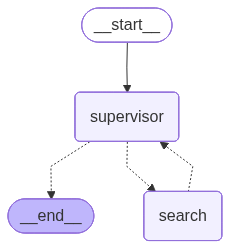

In [126]:
from langgraph.graph import StateGraph

research_graph = StateGraph(State)

research_graph.add_node('supervisor', research_supervisor_node)
research_graph.add_node('search', search_node)

research_graph.set_entry_point('supervisor')
research_graph = research_graph.compile()
research_graph

In [127]:
temp_dir = TemporaryDirectory()
woking_dir = Path(temp_dir.name)
print(woking_dir)

@tool
def create_outline(
    points:Annotated[List[str], "List of main points or sections."],
    file_name:Annotated[str, "File path to save the outline."]
)->Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""

    with(woking_dir/file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i+1}.{point}\n")
    
    return f"Outline saved to {file_name}"

@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."]
)->Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with(woking_dir/file_name).open("w") as file:
            file.write(content)
    
    return f"Document saved to {file_name}"

@tool
def edit_document(
     file_name: Annotated[str, "Path of the document to be edited."],
     inserts: Annotated[
          Dict[int, str],
          "Dictionary where key is the line number (1-index) and value is the text to be inserted at that line",
     ],
)->Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with(woking_dir/file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
              lines.insert(line_number-1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."
        
    with (woking_dir/file_name).open("w") as file:
         file.writelines(lines)

    return f"Document edited and saved to {file_name}"

@tool
def read_document(
     file_name: Annotated[str, "File path to read document from."],
     start: Annotated[Optional[int], "The start line. Default is 0"] = None,
     end: Annotated[Optional[int], "The end line. Default is None"] = None
)->str:
    """Read the specified document."""
    with(woking_dir/file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])

class PythonRunner:
    def __init__(self):
        self._globals = {}

    def run(self, code: str):
        try:
            exec(code, self._globals)
            return self._globals.get("_", None)
        except Exception as e:
            return str(e)

runner = PythonRunner()

@tool
def python_runner_tool(
    code:Annotated[str, "The python code to execute to generate your chart."]
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with'print(...)'. This is visible to the user."""
    try:
        result = runner.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n'''python\n{code}\n'''\nStdout: {result}"

C:\Users\PHUCTH~1\AppData\Local\Temp\tmpbge22tuf


In [128]:
doc_writer_agent = create_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    system_prompt=(
        "You can read, write and edit documents based on note-taker's outlines. "
        "Don't ask follow-up questions."
    )
)

def doc_writing_node(state:State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(content=result['messages'][-1].content, name='doc_writer')
            ]
        },
        goto="Supervisor",
    )

note_taking_agent = create_agent(
    llm,
    tools=[create_outline, read_document],
    system_prompt=(
        "You can read documents and create outlines for the document writer. "
        "Don't ask follow-up questions."
    )
)

def note_taking_node(state:State)->Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(content=result['messages'][-1].content, name='note_taker')
            ]
        },
        goto="Supervisor",
    )

chart_generating_agent = create_agent(
    llm,
    tools=[read_document, python_runner_tool]
)

def chart_generating_node(state:State)->Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(
                    content=result["messages"][-1].content, name="chart_generator"
                )
            ]
        },
        goto="supervisor"
    )

doc_writing_supervisor_node = make_supervisor_node(
    llm,
    ['doc_writer', 'note_taker', 'chart_generator']
)

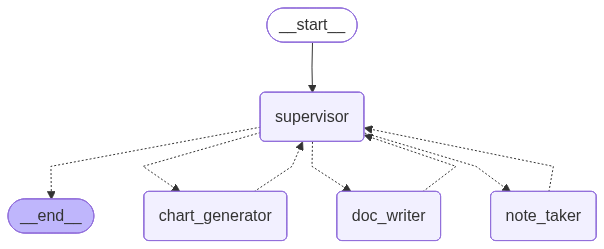

In [129]:
paper_writing_builder = StateGraph(State)
paper_writing_builder.add_node("supervisor", doc_writing_supervisor_node)
paper_writing_builder.add_node("doc_writer", doc_writing_node)
paper_writing_builder.add_node("note_taker", note_taking_node)
paper_writing_builder.add_node("chart_generator", chart_generating_node)

paper_writing_builder.set_entry_point("supervisor")
paper_writing_graph = paper_writing_builder.compile()
paper_writing_graph

In [130]:
from langchain_core.messages import BaseMessage

teams_supervisor_node = make_supervisor_node(
    llm,
    ["research_team", "writing_team"]
)

In [131]:
def call_research_team(state:State)->Command[Literal["supervisor"]]:
    response = research_graph.invoke({
        "messages":state["messages"][-1]
    })
    return Command(
        update={
            "messages":[
                HumanMessage(
                    content=response["messages"][-1].content,
                    name="research_team"
                )
            ]
        },
        goto="supervisor"
    )

def call_paper_writing_team(state:State)->Command[Literal["supervisor"]]:
    response = paper_writing_graph.invoke({
        "messages":state["messages"][-1]
    })
    return Command(
        update={
            "messages":[
                HumanMessage(
                    content=response["messages"][-1].content,
                    name="writing_team"
                )
            ]
        },
        goto="supervisor"
    )

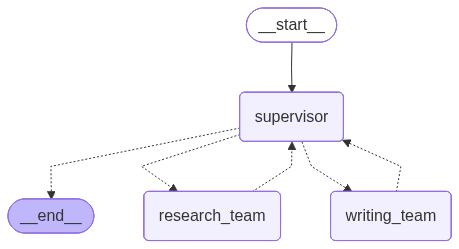

In [132]:
super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor_node)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_paper_writing_team)

super_builder.set_entry_point("supervisor")
super_graph = super_builder.compile()
super_graph

In [ ]:
response=super_graph.invoke(
    {
        "messages": [
            ("user", "Write about transformer variants in production deployments.")
        ],
    }
)
for message in response['messages']:
    print(message.content,'\n\n')

Write about transformer variants in production deployments. 


Deploying transformer variants in production involves a comprehensive approach with strategies designed to optimize performance, manage resources, and ensure scalability. Here's a detailed overview of key practices and tools utilized in such deployments:

1. **Model Optimization:**
   - For edge deployments where resources are limited, lightweight transformer variants like MobileBERT and TinyBERT are utilized. These models use techniques such as distillation and architectural simplification to maintain performance while reducing size and computational demands.
   - Self-attention innovations, such as FlashAttention and LongNet, are used to mitigate the computational intensity associated with standard transformers, especially when handling long sequences. These refinements enhance memory efficiency and computational speed.

2. **Inference Optimization:**
   - Tools like ONNX Runtime and Nvidia's Triton inference server are c

In [135]:
response

{'messages': [HumanMessage(content='Write about transformer variants in production deployments.', additional_kwargs={}, response_metadata={}, id='1c76500d-965c-4356-b827-42fff4d9d0c5'),
  HumanMessage(content="Deploying transformer variants in production involves a comprehensive approach with strategies designed to optimize performance, manage resources, and ensure scalability. Here's a detailed overview of key practices and tools utilized in such deployments:\n\n1. **Model Optimization:**\n   - For edge deployments where resources are limited, lightweight transformer variants like MobileBERT and TinyBERT are utilized. These models use techniques such as distillation and architectural simplification to maintain performance while reducing size and computational demands.\n   - Self-attention innovations, such as FlashAttention and LongNet, are used to mitigate the computational intensity associated with standard transformers, especially when handling long sequences. These refinements enh